### Model Training

In [1]:
# Basic Import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

# Model Selection
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV

# Preprocessing
from sklearn.preprocessing import StandardScaler

# Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, precision_recall_curve, auc
)

# Classification Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier,AdaBoostClassifier)
from sklearn.svm import SVC
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

# Warnings
import warnings
warnings.filterwarnings('ignore')

Import the CSV Data as Pandas DataFrame

In [2]:
df = pd.read_csv('credit_data.csv')

Show Top 5 Records 

In [3]:
df.head()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


Remove Duplicates

In [4]:
df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (150000, 12)


Handle Missing Values

- MonthlyIncome -> median
- NumberOfDependents -> 0

In [5]:
df["MonthlyIncome"] = df["MonthlyIncome"].fillna(df["MonthlyIncome"].median())
df["NumberOfDependents"] = df["NumberOfDependents"].fillna(0)

print(df.isnull().sum())

Unnamed: 0                              0
SeriousDlqin2yrs                        0
RevolvingUtilizationOfUnsecuredLines    0
age                                     0
NumberOfTime30-59DaysPastDueNotWorse    0
DebtRatio                               0
MonthlyIncome                           0
NumberOfOpenCreditLinesAndLoans         0
NumberOfTimes90DaysLate                 0
NumberRealEstateLoansOrLines            0
NumberOfTime60-89DaysPastDueNotWorse    0
NumberOfDependents                      0
dtype: int64


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Unnamed: 0                            150000 non-null  int64  
 1   SeriousDlqin2yrs                      150000 non-null  int64  
 2   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 3   age                                   150000 non-null  int64  
 4   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 5   DebtRatio                             150000 non-null  float64
 6   MonthlyIncome                         150000 non-null  float64
 7   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 8   NumberOfTimes90DaysLate               150000 non-null  int64  
 9   NumberRealEstateLoansOrLines          150000 non-null  int64  
 10  NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 11  

Preparing X and Y Variable

In [7]:
X = df.drop(columns=['Unnamed: 0','SeriousDlqin2yrs'],axis=1)

In [8]:
y = df['SeriousDlqin2yrs']

Train/Test Split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
print(X_train.shape, X_test.shape)

(120000, 10) (30000, 10)


Feature Scaling

In [10]:
scaler = StandardScaler()
X_train_scaled =scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Handle imbalanced data with SMOTE

In [11]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

Create an Evaluate Function to give all metrics after model Training

In [12]:
def evaluate_model(true, predicted):
    acc = accuracy_score(true, predicted)
    prec = precision_score(true, predicted)
    rec = recall_score(true, predicted)
    f1 = f1_score(true, predicted)
    roc = roc_auc_score(true, predicted)

    precision, recall, _ = precision_recall_curve(true, predicted)
    pr_auc = auc(recall, precision)

    return acc, prec, rec, f1, roc, pr_auc

Logestic Regression
Model performance for Training set
- accuracy_score: 0.7057
- precision_score: 0.7295
- recall_score: 0.6538
- f1_score: 0.6896
- ROC-AUC: 0.7057
- PR-AUC: 0.7782
----------------------------------
Model performance for Test set
- accuracy_score: 0.7537
- precision_score: 0.1596
- recall_score: 0.6513
- f1_score: 0.2564
- ROC-AUC: 0.7061
- PR-AUC: 0.4168
----------------------------------


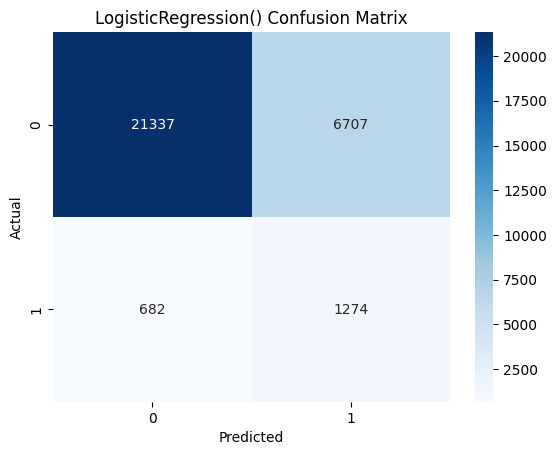



K-Neighbors Classifier
Model performance for Training set
- accuracy_score: 0.9308
- precision_score: 0.8964
- recall_score: 0.9742
- f1_score: 0.9336
- ROC-AUC: 0.9308
- PR-AUC: 0.9417
----------------------------------
Model performance for Test set
- accuracy_score: 0.8171
- precision_score: 0.1741
- recall_score: 0.4821
- f1_score: 0.2558
- ROC-AUC: 0.6613
- PR-AUC: 0.3450
----------------------------------


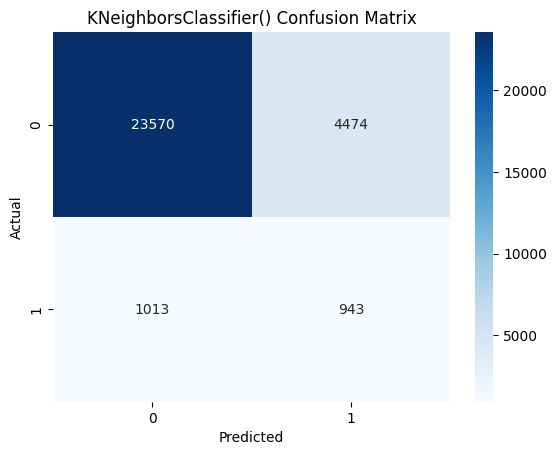



Decision Tree
Model performance for Training set
- accuracy_score: 0.9998
- precision_score: 0.9998
- recall_score: 0.9997
- f1_score: 0.9998
- ROC-AUC: 0.9998
- PR-AUC: 0.9998
----------------------------------
Model performance for Test set
- accuracy_score: 0.8625
- precision_score: 0.1866
- recall_score: 0.3303
- f1_score: 0.2385
- ROC-AUC: 0.6149
- PR-AUC: 0.2803
----------------------------------


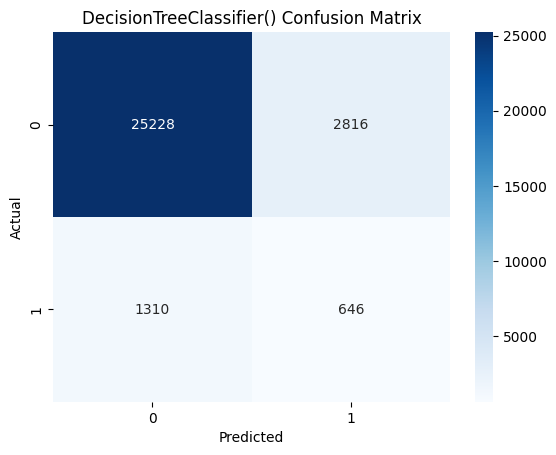



Random Forest Classifier
Model performance for Training set
- accuracy_score: 0.9997
- precision_score: 0.9997
- recall_score: 0.9998
- f1_score: 0.9997
- ROC-AUC: 0.9997
- PR-AUC: 0.9998
----------------------------------
Model performance for Test set
- accuracy_score: 0.9157
- precision_score: 0.3546
- recall_score: 0.3574
- f1_score: 0.3560
- ROC-AUC: 0.6560
- PR-AUC: 0.3770
----------------------------------


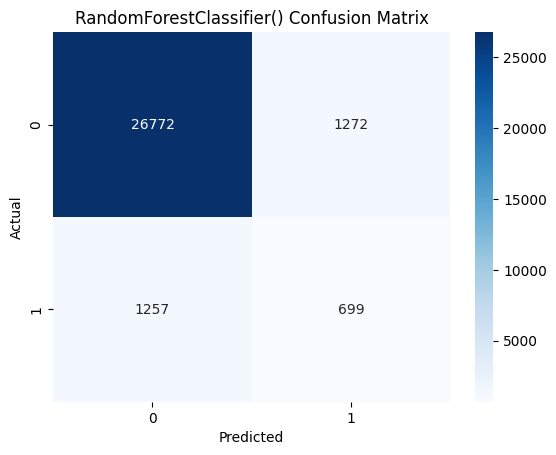



XGBClassifier
Model performance for Training set
- accuracy_score: 0.9589
- precision_score: 0.9822
- recall_score: 0.9348
- f1_score: 0.9579
- ROC-AUC: 0.9589
- PR-AUC: 0.9748
----------------------------------
Model performance for Test set
- accuracy_score: 0.9315
- precision_score: 0.4561
- recall_score: 0.2658
- f1_score: 0.3359
- ROC-AUC: 0.6219
- PR-AUC: 0.3849
----------------------------------


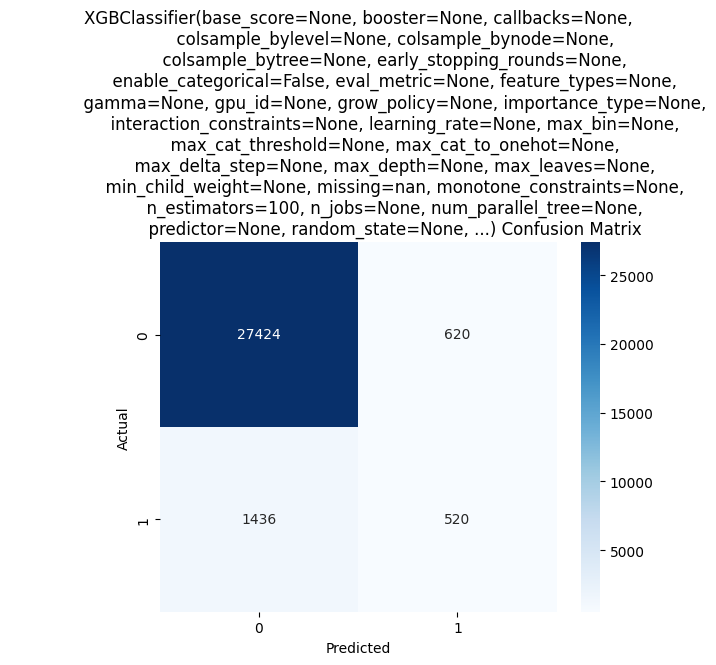



AdaBoost Classifier
Model performance for Training set
- accuracy_score: 0.8296
- precision_score: 0.8365
- recall_score: 0.8194
- f1_score: 0.8279
- ROC-AUC: 0.8296
- PR-AUC: 0.8731
----------------------------------
Model performance for Test set
- accuracy_score: 0.8330
- precision_score: 0.2322
- recall_score: 0.6769
- f1_score: 0.3458
- ROC-AUC: 0.7604
- PR-AUC: 0.4651
----------------------------------


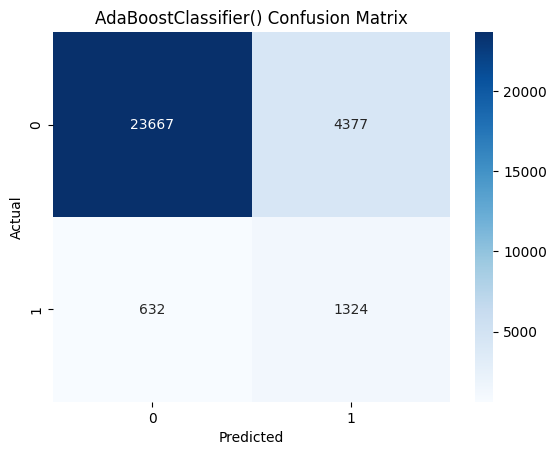

In [13]:
models = {
    "Logestic Regression": LogisticRegression(),
    "K-Neighbors Classifier": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest Classifier": RandomForestClassifier(),
    "XGBClassifier": XGBClassifier(), 
    "AdaBoost Classifier": AdaBoostClassifier()
}
model_list = []
roc_list =[]

for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train_smote, y_train_smote) # Train model

    # Make predictions
    y_train_pred = model.predict(X_train_smote)
    y_test_pred = model.predict(X_test_scaled)
    
    # Evaluate Train and Test dataset
    model_train_acc , model_train_prec, model_train_rec, model_train_f1, model_train_roc, model_train_pr_auc = evaluate_model(y_train_smote, y_train_pred)

    model_test_acc , model_test_prec, model_test_rec, model_test_f1, model_test_roc, model_test_pr_auc = evaluate_model(y_test, y_test_pred)

    
    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])
    
    print('Model performance for Training set')
    print("- accuracy_score: {:.4f}".format(model_train_acc))
    print("- precision_score: {:.4f}".format(model_train_prec))
    print("- recall_score: {:.4f}".format(model_train_rec))
    print("- f1_score: {:.4f}".format(model_train_f1))
    print("- ROC-AUC: {:.4f}".format(model_train_roc))
    print("- PR-AUC: {:.4f}".format(model_train_pr_auc))

    print('----------------------------------')
    
    print('Model performance for Test set')
    print("- accuracy_score: {:.4f}".format(model_test_acc))
    print("- precision_score: {:.4f}".format(model_test_prec))
    print("- recall_score: {:.4f}".format(model_test_rec))
    print("- f1_score: {:.4f}".format(model_test_f1))
    print("- ROC-AUC: {:.4f}".format(model_test_roc))
    print("- PR-AUC: {:.4f}".format(model_test_pr_auc))
    roc_list.append(model_test_roc)

    print('----------------------------------')

    cm = confusion_matrix(y_test, y_test_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{model} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()
    
    print('='*35)
    print('\n')

Result

In [14]:
pd.DataFrame(list(zip(model_list, roc_list)), columns=['Model Name', 'roc_Score']).sort_values(by=["roc_Score"],ascending=False)

,Model Name,roc_Score
5,AdaBoost Classifier,0.760408
0,Logestic Regression,0.706085
1,K-Neighbors Classifier,0.661286
3,Random Forest Classifier,0.656002
4,XGBClassifier,0.621870
2,Decision Tree,0.614926


AdaBoost Classifier

In [15]:
ab_model = AdaBoostClassifier()
ab_model = ab_model.fit(X_train_smote, y_train_smote)
y_pred = ab_model.predict(X_test_scaled)
score = accuracy_score(y_test, y_pred)*100
print(" Accuracy of the model is %.2f" %score)

 Accuracy of the model is 83.30
